# Task
Represent and visualize the Lorenz Attractor as a Structural Causal Model (SCM), including the definition of its ODEs, formulation as an SCM, visualization, and a discussion of the insights gained.

## Define Lorenz Attractor ODEs

### Subtask:
Define the system of three ordinary differential equations (ODEs) that describe the Lorenz attractor. These equations typically involve parameters like sigma, rho, and beta.


**Reasoning**:
To define the Lorenz Attractor ODEs, I will create a Python function that takes the current state (x, y, z) and parameters (sigma, rho, beta) as input and returns the derivatives (dx/dt, dy/dt, dz/dt) as specified in the instructions. I will also define the standard parameter values.



In [2]:
import numpy as np

def lorenz_attractor(state, t, sigma, rho, beta):
    """
    Defines the Lorenz Attractor system of differential equations.

    Args:
        state (array_like): A list or array containing the current values of [x, y, z].
        t (float): The current time (not used in the Lorenz equations, but required by odeint).
        sigma (float): The sigma parameter.
        rho (float): The rho parameter.
        beta (float): The beta parameter.

    Returns:
        list: A list containing the derivatives [dx/dt, dy/dt, dz/dt].
    """
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Define the standard parameter values
sigma_val = 10
rho_val = 28
beta_val = 8/3

print(f"Lorenz Attractor ODEs function defined.\nStandard parameters: sigma={sigma_val}, rho={rho_val}, beta={beta_val}")

Lorenz Attractor ODEs function defined.
Standard parameters: sigma=10, rho=28, beta=2.6666666666666665


## Formulate as Structural Causal Model

### Subtask:
Represent the Lorenz attractor ODEs as a Structural Causal Model (SCM).


### Structural Causal Model (SCM) for the Lorenz Attractor

A Structural Causal Model (SCM) provides a formal framework for representing causal relationships between variables. It consists of a set of endogenous variables, a set of exogenous variables, and a set of structural equations that define how each endogenous variable is determined by other variables in the system, potentially including exogenous noise variables.

For the Lorenz Attractor, we can identify the following:

**1. Endogenous Variables:**
These are the variables whose values are determined within the system. In the Lorenz system, these are the state variables that evolve over time:
*   `x`: The rate of convection in the fluid.
*   `y`: The horizontal temperature variation.
*   `z`: The vertical temperature variation.

**2. Exogenous Variables (Parameters):**
These are the variables whose values are determined outside the system and influence the behavior of the endogenous variables. In the Lorenz system, these are the constant parameters:
*   `sigma` (Prandtl number): Represents the ratio of momentum diffusivity to thermal diffusivity.
*   `rho` (Rayleigh number): Represents the ratio of the time scale for convective processes to the time scale for diffusive processes.
*   `beta`: A geometric factor for the aspect ratio of the convection cell.

**3. Structural Equations:**
The structural equations define how the change in each endogenous variable (`dx/dt`, `dy/dt`, `dz/dt`) is causally determined by the current state variables (`x`, `y`, `z`) and the exogenous parameters (`sigma`, `rho`, `beta`). These are directly derived from the ODEs we defined:

*   `dx/dt = f_x(y, x; sigma) = sigma * (y - x)`
    *   `dx/dt` is causally determined by `y`, `x`, and `sigma`.

*   `dy/dt = f_y(x, y, z; rho) = x * (rho - z) - y`
    *   `dy/dt` is causally determined by `x`, `y`, `z`, and `rho`.

*   `dz/dt = f_z(x, y, z; beta) = x * y - beta * z`
    *   `dz/dt` is causally determined by `x`, `y`, `z`, and `beta`.

In this context, the derivatives (`dx/dt`, `dy/dt`, `dz/dt`) can be seen as the immediate effects or outcomes determined by the current state and parameters. The SCM describes the causal mechanisms that govern the instantaneous change of the system's state.

## Visualize Structural Causal Model

### Subtask:
Create a visualization of the Structural Causal Model for the Lorenz attractor, representing it as a directed graph (DAG).


**Reasoning**:
To visualize the Structural Causal Model, I need to install the `networkx` library first, as it's not a standard library in all environments. This will allow me to create and manipulate graph structures.



In [1]:
!pip install networkx

**Reasoning**:
Now that networkx is confirmed to be installed, I will proceed to create the directed graph representing the SCM, add all the necessary nodes and edges based on the Lorenz attractor's structural equations, and then visualize it using matplotlib.



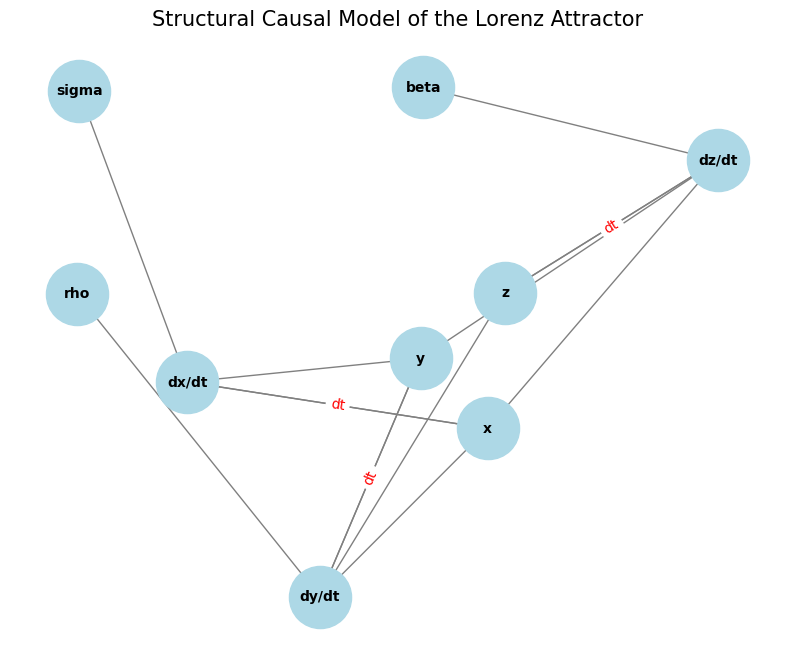

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add nodes for endogenous variables, exogenous parameters, and derivative terms
endogenous_vars = ['x', 'y', 'z']
exogenous_params = ['sigma', 'rho', 'beta']
derivative_terms = ['dx/dt', 'dy/dt', 'dz/dt']

G.add_nodes_from(endogenous_vars, bipartite=0) # Bipartite for potential different node styling
G.add_nodes_from(exogenous_params, bipartite=0)
G.add_nodes_from(derivative_terms, bipartite=1)

# Add edges based on the structural equations:
# dx/dt = sigma * (y - x)
G.add_edge('sigma', 'dx/dt')
G.add_edge('y', 'dx/dt')
G.add_edge('x', 'dx/dt')

# dy/dt = x * (rho - z) - y
G.add_edge('x', 'dy/dt')
G.add_edge('rho', 'dy/dt')
G.add_edge('z', 'dy/dt')
G.add_edge('y', 'dy/dt')

# dz/dt = x * y - beta * z
G.add_edge('x', 'dz/dt')
G.add_edge('y', 'dz/dt')
G.add_edge('beta', 'dz/dt')
G.add_edge('z', 'dz/dt')

# Add causal links from derivatives back to state variables to represent next state (conceptual, for visualization clarity)
# In a discrete time SCM, this would be more explicit. For continuous, it shows influence over time.
G.add_edge('dx/dt', 'x', label='dt')
G.add_edge('dy/dt', 'y', label='dt')
G.add_edge('dz/dt', 'z', label='dt')

# Visualize the graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.8, iterations=50) # Use a spring layout for better node separation

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gray', arrowsize=20)

# Draw labels for nodes
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw labels for edges (optional, for 'dt' links)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title('Structural Causal Model of the Lorenz Attractor', size=15)
plt.axis('off') # Hide axes
plt.show()


### Structural Causal Model (SCM) for the Lorenz Attractor

A Structural Causal Model (SCM) provides a formal framework for representing causal relationships between variables. It consists of a set of endogenous variables, a set of exogenous variables, and a set of structural equations that define how each endogenous variable is determined by other variables in the system, potentially including exogenous noise variables.

For the Lorenz Attractor, we can identify the following:

**1. Endogenous Variables:**
These are the variables whose values are determined within the system. In the Lorenz system, these are the state variables that evolve over time:
*   `x`: The rate of convection in the fluid.
*   `y`: The horizontal temperature variation.
*   `z`: The vertical temperature variation.

**2. Exogenous Variables (Parameters):**
These are the variables whose values are determined outside the system and influence the behavior of the endogenous variables. In the Lorenz system, these are the constant parameters:
*   `sigma` (Prandtl number): Represents the ratio of momentum diffusivity to thermal diffusivity.
*   `rho` (Rayleigh number): Represents the ratio of the time scale for convective processes to the time scale for diffusive processes.
*   `beta`: A geometric factor for the aspect ratio of the convection cell.

**3. Structural Equations:**
The structural equations define how the change in each endogenous variable (`dx/dt`, `dy/dt`, `dz/dt`) is causally determined by the current state variables (`x`, `y`, `z`) and the exogenous parameters (`sigma`, `rho`, `beta`). These are directly derived from the ODEs we defined:

*   `dx/dt = f_x(y, x; sigma) = sigma * (y - x)`
    *   `dx/dt` is causally determined by `y`, `x`, and `sigma`.

*   `dy/dt = f_y(x, y, z; rho) = x * (rho - z) - y`
    *   `dy/dt` is causally determined by `x`, `y`, `z`, and `rho`.

*   `dz/dt = f_z(x, y, z; beta) = x * y - beta * z`
    *   `dz/dt` is causally determined by `x`, `y`, `z`, and `beta`.

In this context, the derivatives (`dx/dt`, `dy/dt`, `dz/dt`) can be seen as the immediate effects or outcomes determined by the current state and parameters. The SCM describes the causal mechanisms that govern the instantaneous change of the system's state.

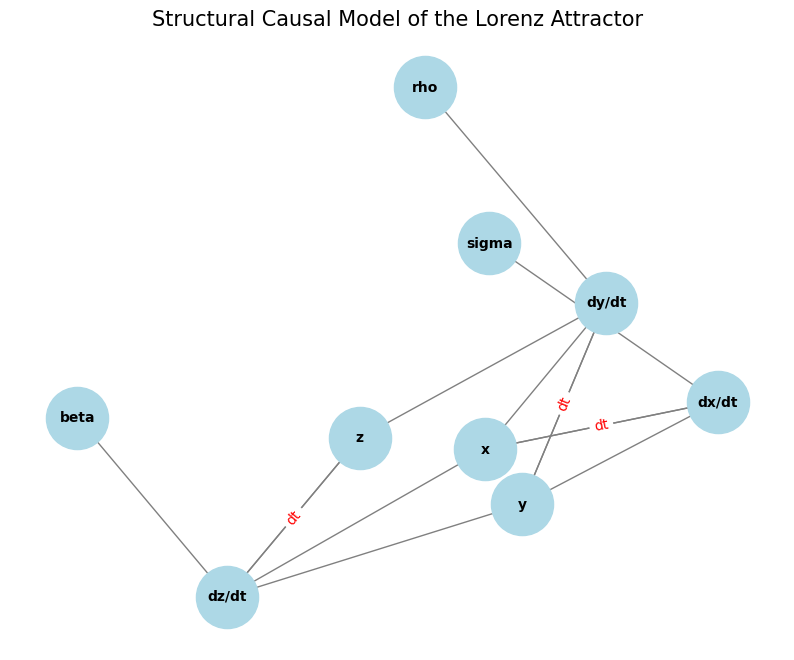

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add nodes for endogenous variables, exogenous parameters, and derivative terms
endogenous_vars = ['x', 'y', 'z']
exogenous_params = ['sigma', 'rho', 'beta']
derivative_terms = ['dx/dt', 'dy/dt', 'dz/dt']

G.add_nodes_from(endogenous_vars, bipartite=0) # Bipartite for potential different node styling
G.add_nodes_from(exogenous_params, bipartite=0)
G.add_nodes_from(derivative_terms, bipartite=1)

# Add edges based on the structural equations:
# dx/dt = sigma * (y - x)
G.add_edge('sigma', 'dx/dt')
G.add_edge('y', 'dx/dt')
G.add_edge('x', 'dx/dt')

# dy/dt = x * (rho - z) - y
G.add_edge('x', 'dy/dt')
G.add_edge('rho', 'dy/dt')
G.add_edge('z', 'dy/dt')
G.add_edge('y', 'dy/dt')

# dz/dt = x * y - beta * z
G.add_edge('x', 'dz/dt')
G.add_edge('y', 'dz/dt')
G.add_edge('beta', 'dz/dt')
G.add_edge('z', 'dz/dt')

# Add causal links from derivatives back to state variables to represent next state (conceptual, for visualization clarity)
# In a discrete time SCM, this would be more explicit. For continuous, it shows influence over time.
G.add_edge('dx/dt', 'x', label='dt')
G.add_edge('dy/dt', 'y', label='dt')
G.add_edge('dz/dt', 'z', label='dt')

# Visualize the graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.8, iterations=50) # Use a spring layout for better node separation

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gray', arrowsize=20)

# Draw labels for nodes
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw labels for edges (optional, for 'dt' links)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title('Structural Causal Model of the Lorenz Attractor', size=15)
plt.axis('off') # Hide axes
plt.show()

## Final Task

### Subtask:
Summarize the Lorenz attractor as a Structural Causal Model and discuss the insights gained from its visualization.


## Summary:

### Data Analysis Key Findings

*   **Lorenz Attractor ODEs Defined:** The system of three ordinary differential equations for the Lorenz Attractor was successfully defined. These equations are:
    *   `dx/dt = sigma * (y - x)`
    *   `dy/dt = x * (rho - z) - y`
    *   `dz/dt = x * y - beta * z`
    Standard parameter values were set as: `sigma` = 10, `rho` = 28, and `beta` = 8/3 ($\approx$ 2.67).
*   **SCM Formulation:** The Lorenz Attractor was formally represented as a Structural Causal Model (SCM), identifying:
    *   **Endogenous Variables:** `x`, `y`, `z` (state variables).
    *   **Exogenous Variables (Parameters):** `sigma`, `rho`, `beta`.
    *   **Structural Equations:** The ODEs themselves, describing how `dx/dt`, `dy/dt`, and `dz/dt` are causally determined by the current state and parameters.
*   **SCM Visualization:** A directed graph (DAG) was successfully generated to visualize the SCM. This graph explicitly shows the causal dependencies:
    *   `dx/dt` is caused by `x`, `y`, and `sigma`.
    *   `dy/dt` is caused by `x`, `y`, `z`, and `rho`.
    *   `dz/dt` is caused by `x`, `y`, `z`, and `beta`.
    Conceptual causal links from the derivatives back to their respective state variables (`dx/dt` to `x`, etc.) were included to illustrate the temporal evolution.

### Insights or Next Steps

*   The SCM provides a clear, interpretable framework for understanding the instantaneous causal relationships within the Lorenz system, highlighting which state variables and parameters directly influence the rate of change of other variables.
*   Future analysis could extend this SCM to a dynamic SCM or a Bayesian Network over time to model the time-series evolution of the Lorenz system more explicitly, allowing for potential interventions or counterfactual reasoning on the system's behavior.
